# Simple Fluid Sim

Stable Fluids (Jos Stam) on an open domain, no obstacles. The solver itself
lives in `fluid_sim.py`; see `Fluid Sim Obstacle.ipynb` for the same solver
with a solid boundary mask. Every figure and animation this notebook makes is
saved as a file under `media/`, not just rendered inline.

In [1]:
%matplotlib inline
from pathlib import Path
import torch
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import imageio_ffmpeg
from IPython.display import Image, display
import fluid_sim as fs

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
matplotlib.rcParams['animation.ffmpeg_path'] = imageio_ffmpeg.get_ffmpeg_exe()
MEDIA_DIR = Path('media')
MEDIA_DIR.mkdir(exist_ok=True)

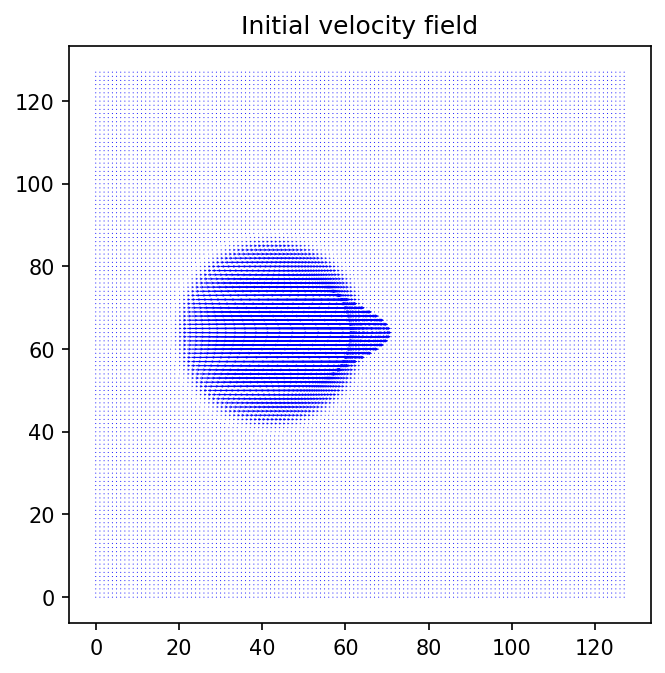

In [2]:
# Initial density + velocity: a warm blob moving in +x
N = 128
dt = 0.01
dx = 1 / N

x = torch.linspace(0, N - 1, N)
y = torch.linspace(0, N - 1, N)
X, Y = torch.meshgrid(x, y, indexing='ij')

rho0 = torch.exp(-((X - N // 3) ** 2 + (Y - N // 2) ** 2) / (2 * (N // 16) ** 2))
rho = rho0.clone()
ux0 = rho0.clone() * 10
ux = ux0.clone()
uy0 = torch.zeros((N, N))
uy = torch.zeros((N, N))

fig = plt.figure(figsize=(5, 5))
plt.quiver(ux0.numpy().T, uy0.numpy().T, color='blue', scale=50, headlength=3, headaxislength=2, width=0.002)
plt.title('Initial velocity field')
fig.savefig(MEDIA_DIR / 'simple_initial_velocity.png', dpi=150, bbox_inches='tight')
plt.close(fig)
display(Image(filename=MEDIA_DIR / 'simple_initial_velocity.png'))

In [3]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.set_facecolor('white')
im = ax.imshow(rho.numpy().T, cmap='inferno', vmin=0, vmax=1, origin='lower', interpolation='bilinear')
ax.set_title('Density Field')
plt.colorbar(im, ax=ax, label='Density')

def update(frame):
    global rho, ux, uy, rho0, ux0, uy0
    if frame < 1:
        rho0, ux0, uy0 = fs.inject_source_block(rho0, ux0, uy0, 20, 40, rho_0=5, ux_0=4, uy_0=2)
    elif frame == 8:
        rho0, ux0, uy0 = fs.inject_source_block(rho0, ux0, uy0, 90, 40, rho_0=5, ux_0=-2, uy_0=4)
    elif frame == 120:
        rho0, ux0, uy0 = fs.inject_source_block(rho0, ux0, uy0, 64, 50, rho_0=5, ux_0=1, uy_0=4)
        rho0, ux0, uy0 = fs.inject_source_block(rho0, ux0, uy0, 64, 70, rho_0=5, ux_0=-1, uy_0=-4)
    else:
        rho0, ux0, uy0 = rho.clone(), ux.clone(), uy.clone()
    ux, uy = fs.vel_step(ux, uy, ux0, uy0, dt, dx, 0)
    rho = fs.density_step(rho, ux, uy, rho0, 0.05, dt)
    im.set_array(rho.numpy().T)
    return [im]

ani = animation.FuncAnimation(fig, update, frames=300, interval=50, blit=True)
ani.save(MEDIA_DIR / 'simple_fluid_sim.mp4', writer='ffmpeg', fps=20, dpi=80)
plt.close(fig)
print(f"Saved animation to {MEDIA_DIR / 'simple_fluid_sim.mp4'}")

Saved animation to media\simple_fluid_sim.mp4


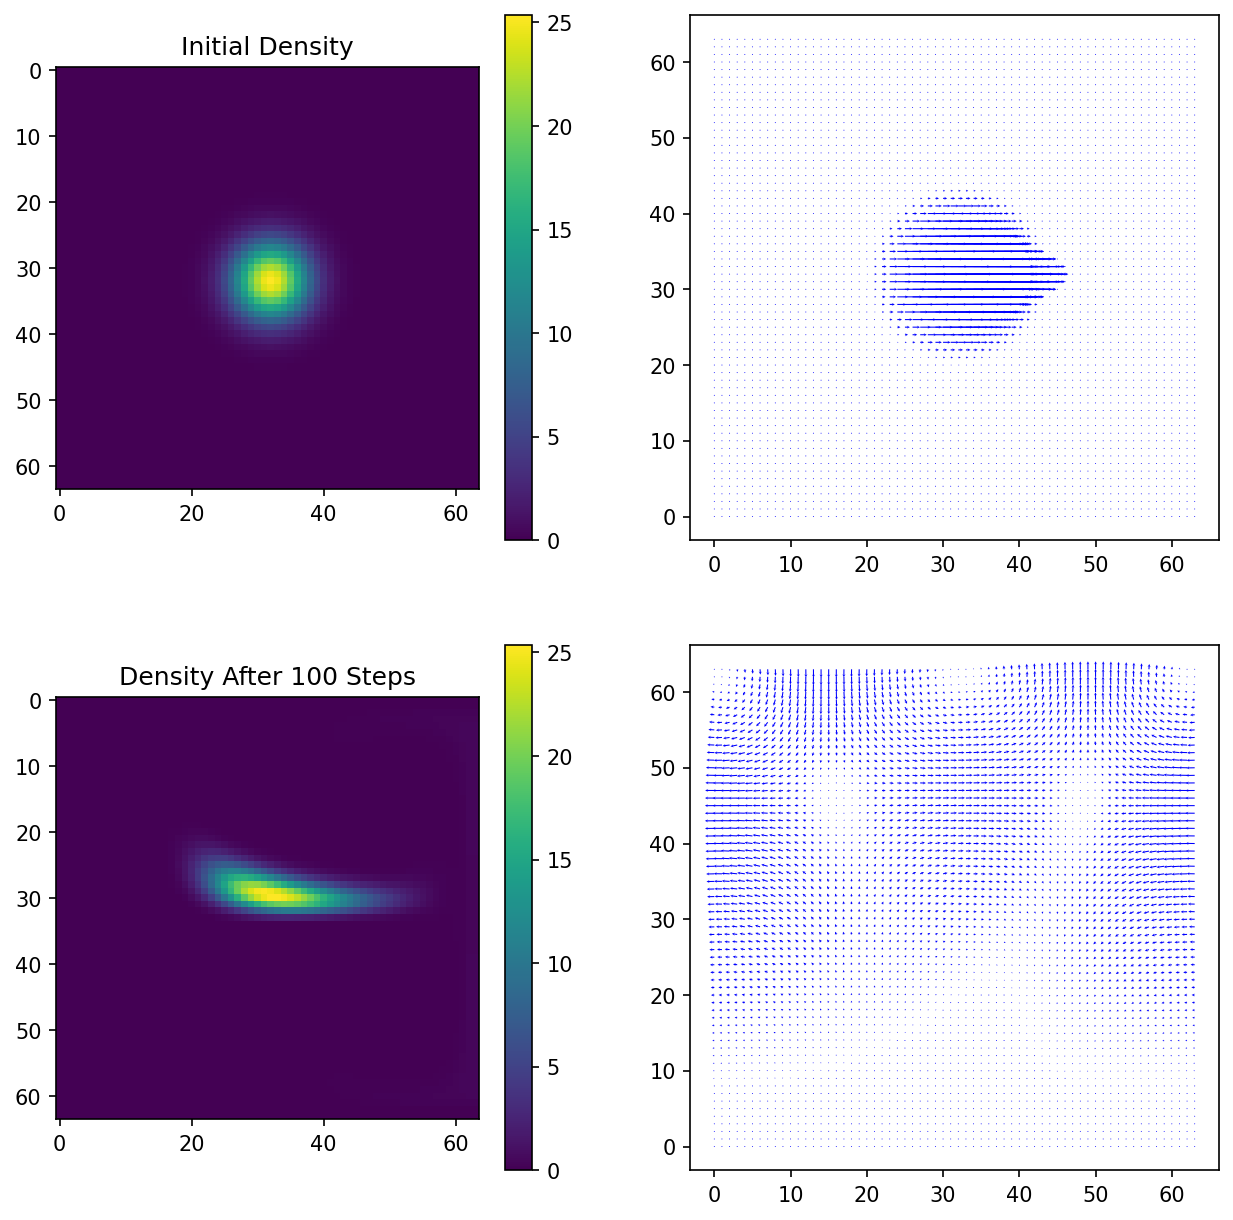

In [4]:
# Static before/after comparison, with viscosity
N = 64
dt = 0.01
dx = 1 / N

x = torch.linspace(0, N - 1, N)
y = torch.linspace(0, N - 1, N)
X, Y = torch.meshgrid(x, y, indexing='ij')

rho0 = torch.exp(-((X - N // 2) ** 2 + (Y - N // 2) ** 2) / (2 * (N // 16) ** 2))
rho = rho0.clone()
ux0 = rho0.clone() * 10
ux = ux0.clone()
uy0 = torch.zeros((N, N))
uy = torch.zeros((N, N))

fig, axes = plt.subplots(2, 2, figsize=(10, 10))
axes[0, 0].imshow(rho.numpy().T, cmap='viridis')
axes[0, 0].set_title('Initial Density')
axes[0, 1].quiver(ux0.numpy(), uy0.numpy(), color='blue', scale=50, headlength=3, headaxislength=2, width=0.002)

for i in range(100):
    if i < 10:
        rho0, ux0, uy0 = fs.inject_source_block(rho0, ux0, uy0, 15, 15, rho_0=10, ux_0=3, uy_0=3)
    else:
        rho0, ux0, uy0 = rho.clone(), ux.clone(), uy.clone()
    ux, uy = fs.vel_step(ux, uy, ux0, uy0, dt, dx, 0.01)
    rho = fs.density_step(rho, ux, uy, rho0, 0.01, dt)

im = axes[1, 0].imshow(rho.numpy().T, cmap='viridis', vmin=0)
axes[1, 0].set_title('Density After 100 Steps')
axes[1, 1].quiver(ux.numpy(), uy.numpy(), color='blue', scale=50, headlength=3, headaxislength=2, width=0.002)
plt.colorbar(im, ax=axes[0, 0])
plt.colorbar(im, ax=axes[1, 0])
fig.savefig(MEDIA_DIR / 'simple_before_after.png', dpi=150, bbox_inches='tight')
plt.close(fig)
display(Image(filename=MEDIA_DIR / 'simple_before_after.png'))